In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
file_path = "/content/drive/MyDrive/Colab Notebooks/ProjectML1/project/tech_layoffs.csv"

Mounted at /content/drive


In [ ]:
import pandas as pd
data= pd.read_csv(file_path)
df = pd.DataFrame(data)df.head()

,company,total_layoffs,impacted_workforce_percentage,reported_date,industry,headquarter_location,sources,status,additional_notes
0,C2FO,20.0,2.0,12/9/2022,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private,NaN
1,VideoAmp,NaN,2.0,9/19/2022,Advertising platforms,Los Angeles,Company memo,Private,NaN
2,Amperity,13.0,3.0,8/20/2022,"Saas, analytics",Seattle,Geekwire,Private,NaN
3,Addepar,20.0,3.0,1/18/2023,"fintech, data analytics","Mountain View, CA",Fortune,Private,NaN
4,Thirty Madison,24.0,3.0,5/13/2022,Health Care,New York,Axios,Private,"Per Axios, 22 of the employees laid off were f..."


In [ ]:
#clear some unwanted columns
df.drop(columns=['additional_notes'], inplace=True)
df.drop(columns=['reported_date'],inplace = True)
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,C2FO,20.0,2.0,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private
1,VideoAmp,NaN,2.0,Advertising platforms,Los Angeles,Company memo,Private
2,Amperity,13.0,3.0,"Saas, analytics",Seattle,Geekwire,Private
3,Addepar,20.0,3.0,"fintech, data analytics","Mountain View, CA",Fortune,Private
4,Thirty Madison,24.0,3.0,Health Care,New York,Axios,Private


In [ ]:
#eda
#Checking for nulls
missing_values = df.isnull().sum()
print(missing_values)

company                            0
total_layoffs                    182
impacted_workforce_percentage    133
reported_date                      0
industry                           0
headquarter_location               0
sources                            0
status                             0
additional_notes                 467
dtype: int64


In [ ]:
#replace nulls with mean
replace_totLayoffs = df['total_layoffs'].mean()
df['total_layoffs'].fillna(replace_totLayoffs, inplace=True)
df.head()

<ipython-input-8-5b1c611224f4>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_layoffs'].fillna(replace_totLayoffs, inplace=True)


,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,C2FO,20.000000,2.0,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private
1,VideoAmp,450.019544,2.0,Advertising platforms,Los Angeles,Company memo,Private
2,Amperity,13.000000,3.0,"Saas, analytics",Seattle,Geekwire,Private
3,Addepar,20.000000,3.0,"fintech, data analytics","Mountain View, CA",Fortune,Private
4,Thirty Madison,24.000000,3.0,Health Care,New York,Axios,Private


In [ ]:
#replace nulls with mode
replace_perc=df['impacted_workforce_percentage'].mode()[0]
df['impacted_workforce_percentage'].fillna(replace_perc, inplace=True)
df.head()

<ipython-input-9-45acf0aa6f3c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['impacted_workforce_percentage'].fillna(replace_perc, inplace=True)


,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,C2FO,20.000000,2.0,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private
1,VideoAmp,450.019544,2.0,Advertising platforms,Los Angeles,Company memo,Private
2,Amperity,13.000000,3.0,"Saas, analytics",Seattle,Geekwire,Private
3,Addepar,20.000000,3.0,"fintech, data analytics","Mountain View, CA",Fortune,Private
4,Thirty Madison,24.000000,3.0,Health Care,New York,Axios,Private


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

company                          0
total_layoffs                    0
impacted_workforce_percentage    0
industry                         0
headquarter_location             0
sources                          0
status                           0
dtype: int64


In [ ]:
#encoding company column using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['company'] = label_encoder.fit_transform(df['company'])
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private
1,442,450.019544,2.0,Advertising platforms,Los Angeles,Company memo,Private
2,23,13.000000,3.0,"Saas, analytics",Seattle,Geekwire,Private
3,7,20.000000,3.0,"fintech, data analytics","Mountain View, CA",Fortune,Private
4,416,24.000000,3.0,Health Care,New York,Axios,Private


In [ ]:
#encoding sources column using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['sources'] = label_encoder.fit_transform(df['sources'])
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,"Fintech, payments","Leawood, KS",109,Private
1,442,450.019544,2.0,Advertising platforms,Los Angeles,56,Private
2,23,13.000000,3.0,"Saas, analytics",Seattle,94,Private
3,7,20.000000,3.0,"fintech, data analytics","Mountain View, CA",89,Private
4,416,24.000000,3.0,Health Care,New York,14,Private


In [ ]:
df.duplicated().sum()

0

In [ ]:
#encoding headquarter locations column using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['headquarter_location'] = label_encoder.fit_transform(df['headquarter_location'])
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,"Fintech, payments",51,109,Private
1,442,450.019544,2.0,Advertising platforms,56,56,Private
2,23,13.000000,3.0,"Saas, analytics",113,94,Private
3,7,20.000000,3.0,"fintech, data analytics",70,89,Private
4,416,24.000000,3.0,Health Care,76,14,Private


In [ ]:
#encoding industry column using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['industry'] = label_encoder.fit_transform(df['industry'])
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,98,51,109,Private
1,442,450.019544,2.0,11,56,56,Private
2,23,13.000000,3.0,184,113,94,Private
3,7,20.000000,3.0,252,70,89,Private
4,416,24.000000,3.0,109,76,14,Private


In [ ]:
#encoding status column using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['status'] = label_encoder.fit_transform(df['status'])
df.head()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,98,51,109,0
1,442,450.019544,2.0,11,56,56,0
2,23,13.000000,3.0,184,113,94,0
3,7,20.000000,3.0,252,70,89,0
4,416,24.000000,3.0,109,76,14,0


In [ ]:
df

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
0,73,20.000000,2.0,98,51,109,0
1,442,450.019544,2.0,11,56,56,0
2,23,13.000000,3.0,184,113,94,0
3,7,20.000000,3.0,252,70,89,0
4,416,24.000000,3.0,109,76,14,0
...,...,...,...,...,...,...,...
484,361,9090.000000,10.0,251,101,133,1
485,299,450.019544,10.0,181,3,196,1
486,249,450.019544,10.0,51,76,118,1
487,375,450.019544,10.0,150,101,174,1


In [ ]:
#train test split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
data_x = df.iloc[:,:-1].values
data_y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size = 0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
print(y_predict)

[0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0]


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        489 non-null    int64  
 1   total_layoffs                  489 non-null    float64
 2   impacted_workforce_percentage  489 non-null    float64
 3   industry                       489 non-null    int64  
 4   headquarter_location           489 non-null    int64  
 5   sources                        489 non-null    int64  
 6   status                         489 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 26.9 KB


In [ ]:
df.describe()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000
mean,238.535787,450.019544,20.102249,129.856851,76.415133,111.018405,0.243354
std,137.850118,1308.257875,22.044519,75.141615,34.021772,67.547749,0.429546
min,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,73.000000,10.000000,71.000000,56.000000,39.000000,0.000000
50%,239.000000,254.000000,10.000000,114.000000,84.000000,109.000000,0.000000
75%,359.000000,450.019544,20.000000,186.000000,101.000000,186.000000,0.000000
max,476.000000,18000.000000,100.000000,288.000000,133.000000,220.000000,1.000000


In [ ]:
print(y_predict.shape)  # Should match the number of rows in X_test
print(X_test.shape[0])  # Compare with number of rows in X_test


(98,)
98


In [ ]:
#performance metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print(confusion_matrix(y_test,y_predict))
print(accuracy_score(y_test,y_predict))
print(classification_report(y_test,y_predict))

[[67  3]
 [17 11]]
0.7959183673469388
              precision    recall  f1-score   support

           0       0.80      0.96      0.87        70
           1       0.79      0.39      0.52        28

    accuracy                           0.80        98
   macro avg       0.79      0.68      0.70        98
weighted avg       0.79      0.80      0.77        98



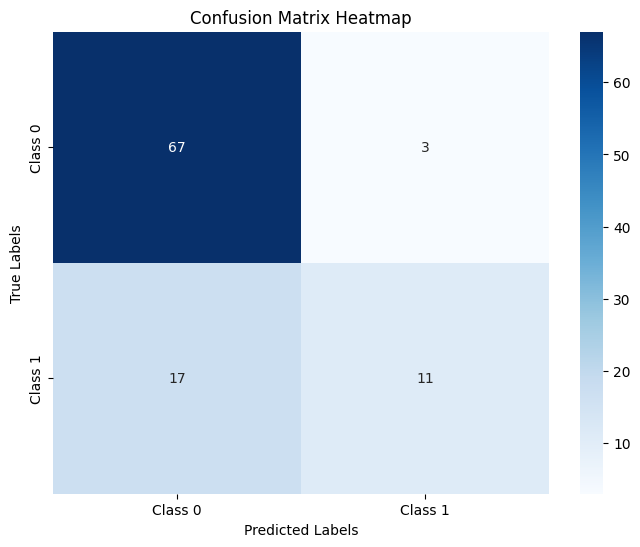

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
df.corr()

,company,total_layoffs,impacted_workforce_percentage,industry,headquarter_location,sources,status
company,1.000000,-0.062616,0.024405,0.025848,0.035266,0.115711,0.067007
total_layoffs,-0.062616,1.000000,-0.012610,-0.029916,0.060215,0.035247,0.236688
impacted_workforce_percentage,0.024405,-0.012610,1.000000,-0.062117,0.022367,0.056719,-0.141566
industry,0.025848,-0.029916,-0.062117,1.000000,-0.064092,0.061575,-0.008251
headquarter_location,0.035266,0.060215,0.022367,-0.064092,1.000000,0.140164,0.059117
sources,0.115711,0.035247,0.056719,0.061575,0.140164,1.000000,-0.006864
status,0.067007,0.236688,-0.141566,-0.008251,0.059117,-0.006864,1.000000


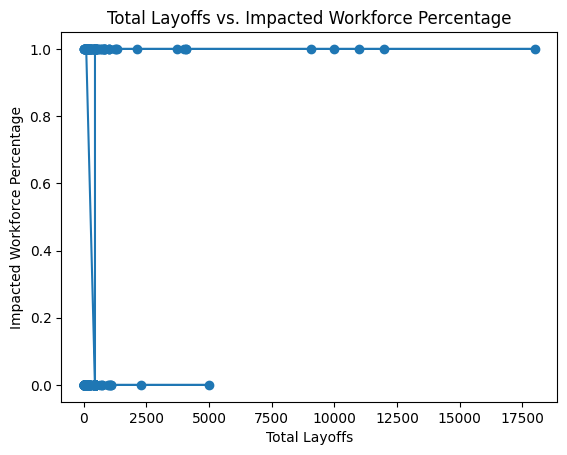

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['total_layoffs'], df['status'], marker='o')

plt.xlabel('Total Layoffs')
plt.ylabel('Impacted Workforce Percentage')
plt.title('Total Layoffs vs. Impacted Workforce Percentage')

plt.show()


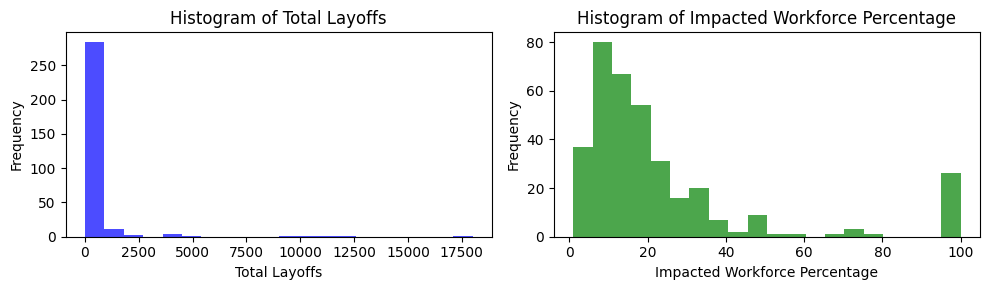

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.hist(df['total_layoffs'], bins=20, alpha=0.7, color='blue')
plt.xlabel('Total Layoffs')
plt.ylabel('Frequency')
plt.title('Histogram of Total Layoffs')

plt.subplot(1, 2, 2)
plt.hist(df['impacted_workforce_percentage'], bins=20, alpha=0.7, color='green')
plt.xlabel('Impacted Workforce Percentage')
plt.ylabel('Frequency')
plt.title('Histogram of Impacted Workforce Percentage')

plt.tight_layout()
plt.show()


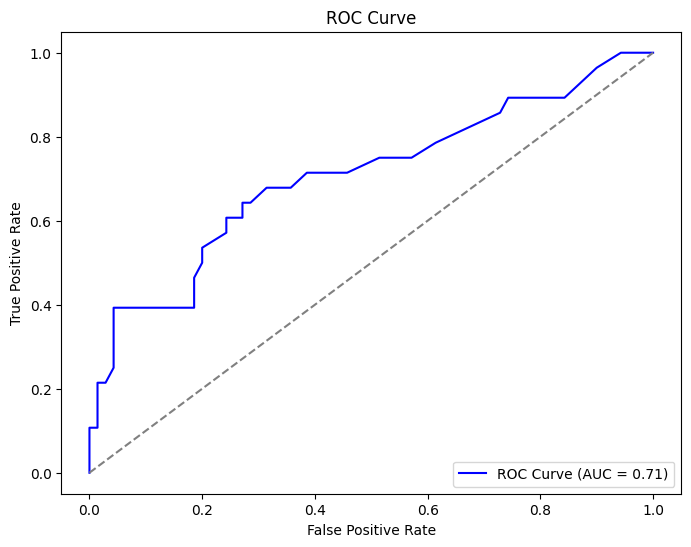

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



#  ROC Curve (Receiver Operating Characteristic)
if len(np.unique(data_y)) == 2:  # to check if the target has 2 unique values(binary)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()


<ipython-input-43-541fe6c0d4e2>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


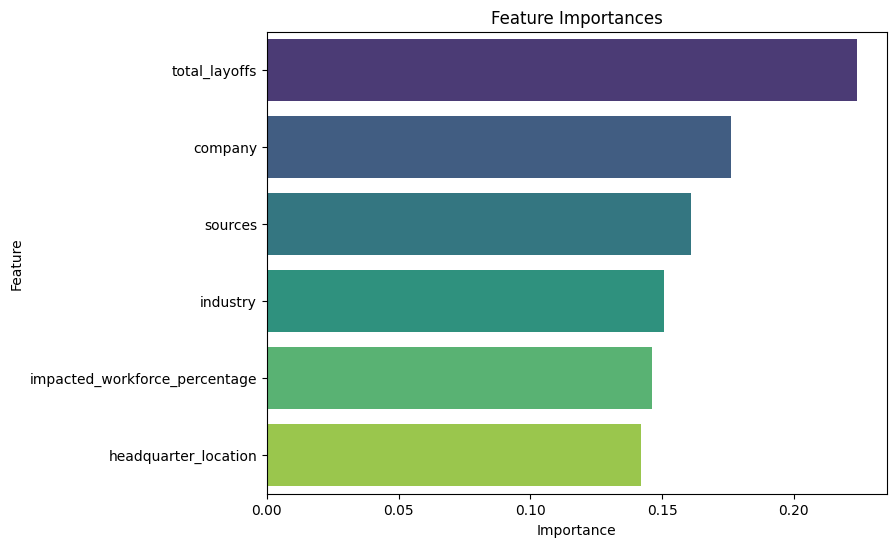

In [ ]:
# Feature Importances
importances = model.feature_importances_  #set the important feature
indices = np.argsort(importances)[::-1]
feature_names = df.columns[:-1]  # All feature column names

plt.figure(figsize=(8, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

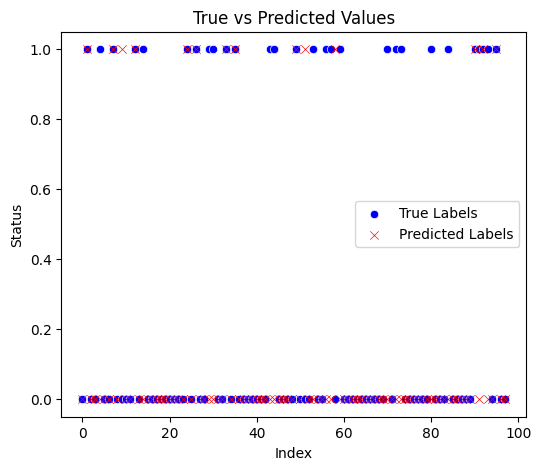

In [ ]:
# Predicted vs True Values
plt.figure(figsize=(6, 5))
sns.scatterplot(x=range(len(y_test)), y=y_test, label="True Labels", color="blue")
sns.scatterplot(x=range(len(y_predict)), y=y_predict, label="Predicted Labels", color="red", marker="x")
plt.title("True vs Predicted Values")
plt.xlabel("Index")
plt.ylabel("Status")
plt.legend()
plt.show()

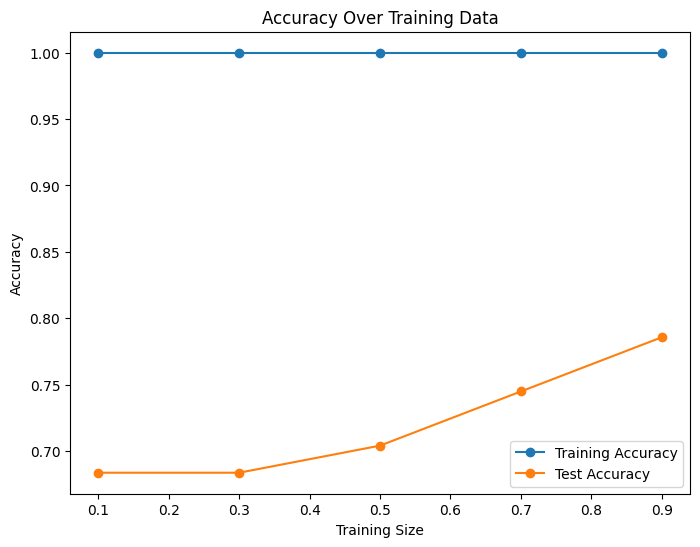

In [ ]:
# Accuracy Over Training Data (optional, if using cross-validation or custom splitting)
training_accuracies = []
test_accuracies = []
train_sizes = np.linspace(0.1, 0.9, 5)

for size in train_sizes:
    X_train_part, _, y_train_part, _ = train_test_split(X_train, y_train, train_size=size, random_state=42) #ignoring the x_test and y_test parts
    model.fit(X_train_part, y_train_part)
    training_accuracies.append(model.score(X_train_part, y_train_part))
    test_accuracies.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, training_accuracies, label="Training Accuracy", marker="o")
plt.plot(train_sizes, test_accuracies, label="Test Accuracy", marker="o")
plt.title("Accuracy Over Training Data")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()